In [25]:
# Choose any appropriate dataset of your choice. 
# Import the dataset using Pandas. 
# Display the first few rows of the dataset and summarize the data types and structure. 
# Calculate and interpret the mean, median, and mode for numerical variables. 
# Calculate and interpret the range, variance, standard deviation, and interquartile range (IQR) for numerical variables.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [27]:
df = sns.load_dataset("penguins")

In [28]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [29]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [30]:
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [32]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [33]:
mean_vals = df.mean(numeric_only=True)
median_vals = df.median(numeric_only=True)
mode_vals = df.mode(numeric_only=True).iloc[0]

print("\nMean:\n", mean_vals)
print("\nMedian:\n", median_vals)
print("\nMode:\n", mode_vals)


Mean:
 bill_length_mm         43.921930
bill_depth_mm          17.151170
flipper_length_mm     200.915205
body_mass_g          4201.754386
dtype: float64

Median:
 bill_length_mm         44.45
bill_depth_mm          17.30
flipper_length_mm     197.00
body_mass_g          4050.00
dtype: float64

Mode:
 bill_length_mm         41.1
bill_depth_mm          17.0
flipper_length_mm     190.0
body_mass_g          3800.0
Name: 0, dtype: float64


In [56]:
# Range, Variance, Std Dev, IQR
range_vals = df.max(numeric_only=True) - df.min(numeric_only=True)
variance_vals = df.var(numeric_only=True)
std_vals = df.std(numeric_only=True)
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR_vals = Q3 - Q1



print("\nRange:\n", range_vals)
print("\nVariance:\n", variance_vals)
print("\nStandard Deviation:\n", std_vals)
print("\nIQR:\n", IQR_vals)


Range:
 bill_length_mm         27.5
bill_depth_mm           8.4
flipper_length_mm      59.0
body_mass_g          3600.0
dtype: float64

Variance:
 bill_length_mm           29.634869
bill_depth_mm             3.877197
flipper_length_mm       196.667698
body_mass_g          639514.543359
dtype: float64

Standard Deviation:
 bill_length_mm         5.443792
bill_depth_mm          1.969060
flipper_length_mm     14.023826
body_mass_g          799.696532
dtype: float64

IQR:
 bill_length_mm          9.225
bill_depth_mm           3.100
flipper_length_mm      23.000
body_mass_g          1200.000
dtype: float64


In [35]:
# 2.	Identify and handle missing values in the dataset through imputation 
# (filling in missing values using a reasonable estimate) or deletion. 
# Identify and visualize outliers using box plots and z-scores. 
# Decide on methods to handle outliers (e.g., removal, transformation).

In [36]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [37]:
# removing missing values
#median imputation
num_cols = ['bill_length_mm', 'bill_depth_mm', 
            'flipper_length_mm', 'body_mass_g']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
    
#mode imputation 
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

In [38]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,Male
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female


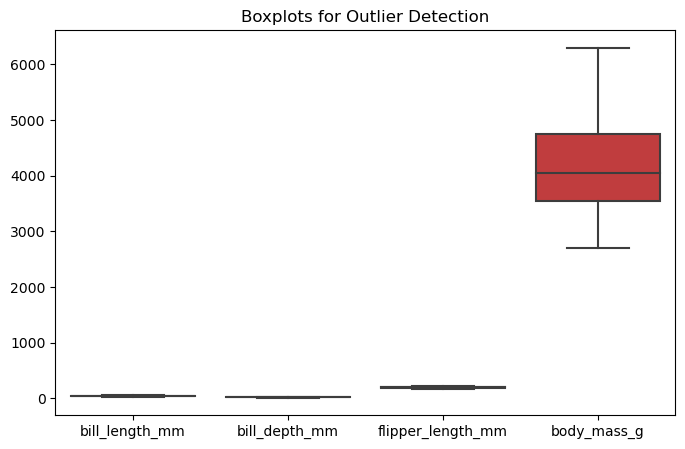


Number of Outliers: 0


In [43]:
# visualization of outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']])
plt.title("Boxplots for Outlier Detection")
plt.show()

# Z-score method
z_scores = np.abs(stats.zscore(df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']]))
outliers = (z_scores > 3).any(axis=1)
print("\nNumber of Outliers:", outliers.sum())



In [45]:
# Create histograms and box plots for numerical variables, and 
# bar charts for categorical variables. Use scatter plots to explore 
# relationships between numerical variables, and pair plots and 
# correlation matrices for multiple variables. Visualize and interpret 
# trends over time or across different variables.

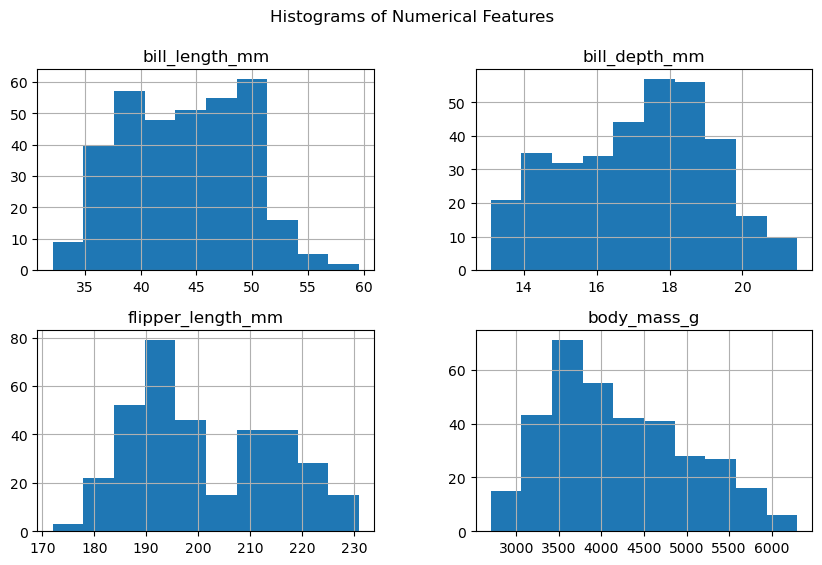

In [46]:
# Histograms
df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']].hist(figsize=(10,6))
plt.suptitle("Histograms of Numerical Features")
plt.show()

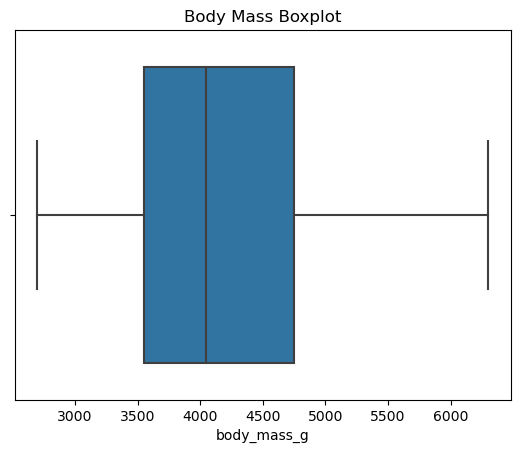

In [47]:
# Boxplot example
sns.boxplot(x=df['body_mass_g'])
plt.title("Body Mass Boxplot")
plt.show()

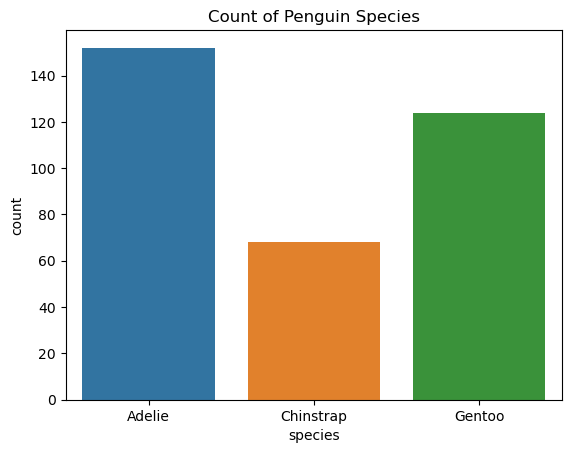

In [48]:
# Bar chart 
sns.countplot(x=df['species'])
plt.title("Count of Penguin Species")
plt.show()

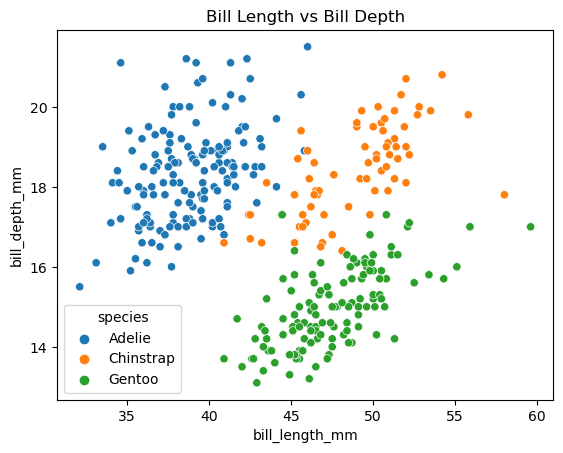

In [49]:
# Scatter plot 
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title("Bill Length vs Bill Depth")
plt.show()

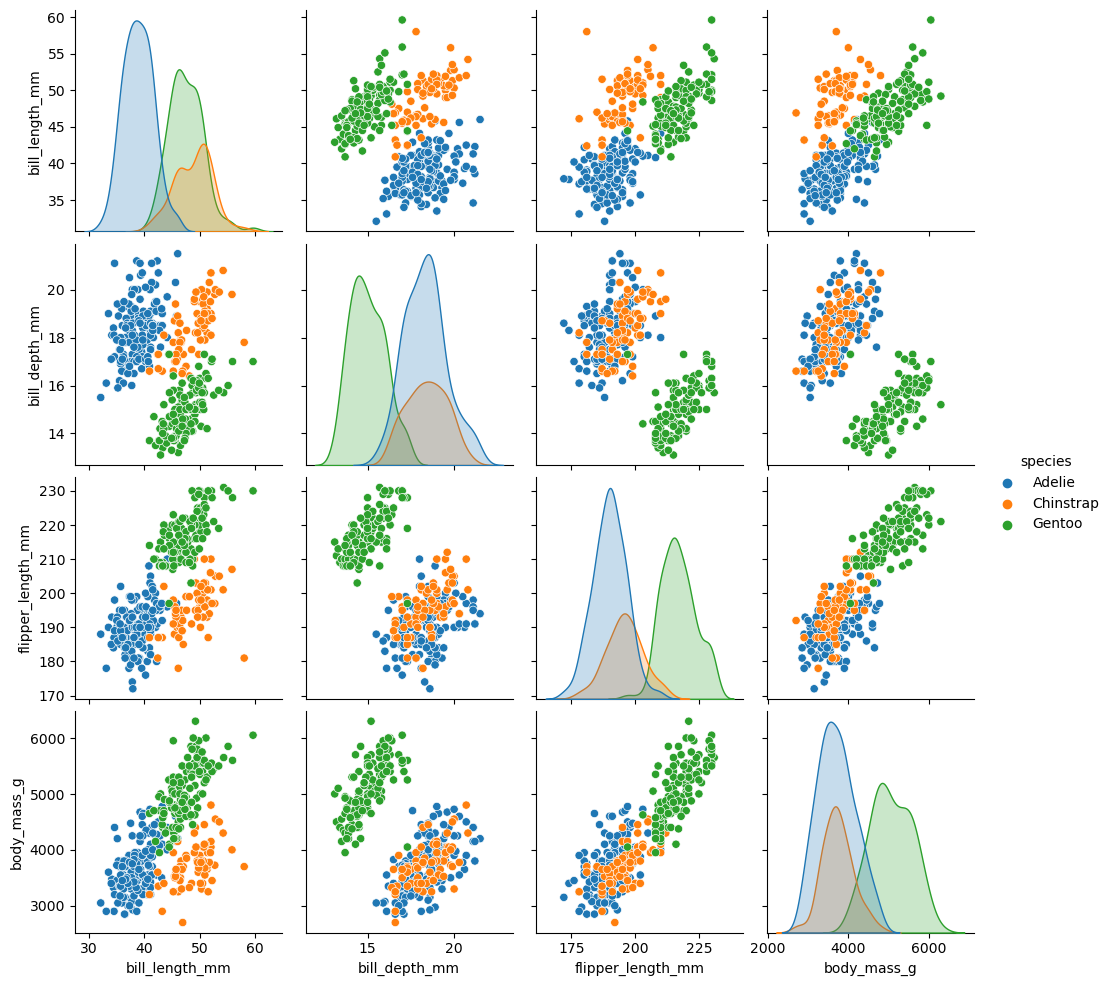

In [51]:
# Pair plot 
sns.pairplot(df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','species']], hue='species')
plt.show()

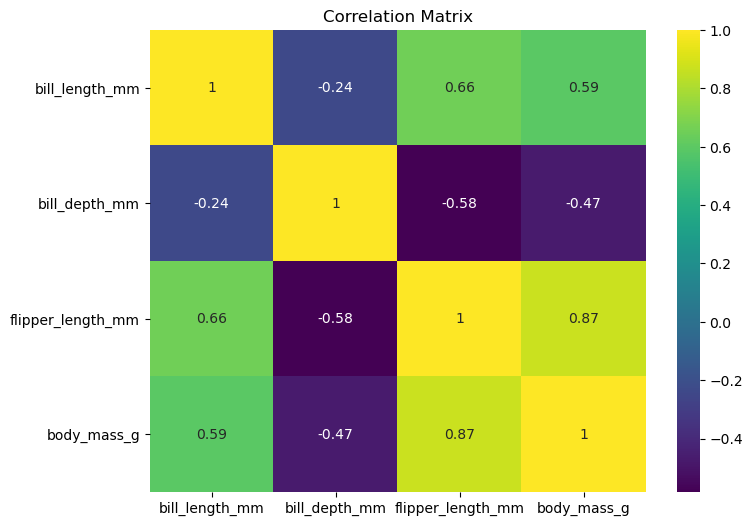

In [52]:
# Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']].corr(),
            annot=True, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

In [60]:
df_clean = df.dropna(subset=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'])

upper = []
lower = []
for col in ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
print(col, "->", "lower:", lower_bound, ", upper:", upper_bound)

body_mass_g -> lower: 1750.0 , upper: 6550.0


In [63]:
df['body_mass_g'].max()

6300.0

In [65]:
df['body_mass_g'].min()

2700.0